In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
df1 = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df2 = pd.read_csv('experiment_metrics_fully_parallel/default2.csv')
df3 = pd.read_csv('experiment_metrics_fully_parallel/default3.csv')

print(df1.columns)

Index(['val/total_mse', 'train/grad_norm', 'train/forces_magnitude_error',
       'train/lr', 'train/epoch', 'train/energy_mae', '_timestamp',
       'val/forces_mae', 'val/energy_mse', 'train/forces_mse',
       'train/energy_rmse', 'train/energy_forces_within_threshold',
       'val/forces_rmse', 'val/energy_mae', 'train/energy_mse',
       'val/energy_rmse', 'val/forces_cosine_similarity',
       'train/forces_cosine_similarity', 'train/step',
       'val/pct_loss_from_equiv_error', '_runtime', 'train/forces_mae',
       'val/loss', 'val/mean_pred_error', 'val/epoch',
       'val/energy_forces_within_threshold', 'train/loss', 'val/forces_mse',
       'val/forces_magnitude_error', 'train/forces_rmse', '_step',
       'val/equiv_error'],
      dtype='object')


In [3]:
mdf = pd.merge(df1, df2, on=['_step'], suffixes=('_1', '_2'))

df3 = df3.rename(columns={c: f'{c}_3' for c in df3.columns if c != '_step'})

mdf = pd.merge(mdf, df3, on=['_step'], suffixes=('', '_3'))

mdf.columns

Index(['val/total_mse_1', 'train/grad_norm_1',
       'train/forces_magnitude_error_1', 'train/lr_1', 'train/epoch_1',
       'train/energy_mae_1', '_timestamp_1', 'val/forces_mae_1',
       'val/energy_mse_1', 'train/forces_mse_1', 'train/energy_rmse_1',
       'train/energy_forces_within_threshold_1', 'val/forces_rmse_1',
       'val/energy_mae_1', 'train/energy_mse_1', 'val/energy_rmse_1',
       'val/forces_cosine_similarity_1', 'train/forces_cosine_similarity_1',
       'train/step_1', 'val/pct_loss_from_equiv_error_1', '_runtime_1',
       'train/forces_mae_1', 'val/loss_1', 'val/mean_pred_error_1',
       'val/epoch_1', 'val/energy_forces_within_threshold_1', 'train/loss_1',
       'val/forces_mse_1', 'val/forces_magnitude_error_1',
       'train/forces_rmse_1', '_step', 'val/equiv_error_1', 'val/epoch_2',
       'val/forces_mse_2', 'val/energy_forces_within_threshold_2',
       'train/energy_mse_2', 'val/energy_mae_2', 'val/energy_mse_2',
       'train/grad_norm_2', 'train/forc

In [4]:
mdf[[
    'val/pct_loss_from_equiv_error_1',
    'val/pct_loss_from_equiv_error_2',
    'val/pct_loss_from_equiv_error_3'
]]

,val/pct_loss_from_equiv_error_1,val/pct_loss_from_equiv_error_2,val/pct_loss_from_equiv_error_3
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
445935,NaN,NaN,NaN
445936,NaN,NaN,NaN
445937,NaN,NaN,NaN
445938,NaN,NaN,NaN


In [5]:
mdfs = mdf[~np.isnan(mdf['val/pct_loss_from_equiv_error_1'])]

mdfs[[
    'val/pct_loss_from_equiv_error_1',
    'val/pct_loss_from_equiv_error_2',
    'val/pct_loss_from_equiv_error_3'
]]

,val/pct_loss_from_equiv_error_1,val/pct_loss_from_equiv_error_2,val/pct_loss_from_equiv_error_3
19,0.181331,0.175909,NaN
39,0.186794,0.183350,NaN
59,0.177711,0.183257,NaN
79,0.178973,0.177713,NaN
99,0.177006,0.165275,0.172163
...,...,...,...
445859,0.000485,0.000697,NaN
445879,0.000507,0.000615,NaN
445899,0.000508,0.000661,NaN
445919,0.000561,0.000579,NaN


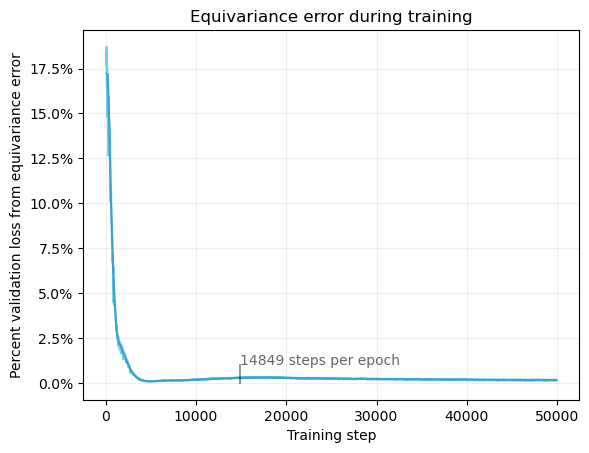

In [6]:
import matplotlib.ticker as mtick

max_x = 50_000

fig, ax = plt.subplots()
sns.lineplot(
    data=mdf[mdf['_step'] < max_x],
    x='_step',
    y='val/pct_loss_from_equiv_error_1',
    color = '#00a0dc',
    errorbar = None,
    alpha=0.5,
    ax = ax,
)
sns.lineplot(
    data=mdf[mdf['_step'] < max_x],
    x='_step',
    y='val/pct_loss_from_equiv_error_2',
    color = '#68c7ec',
    errorbar = None,
    alpha=0.5,
    ax = ax,
)
sns.lineplot(
    data=mdf[mdf['_step'] < max_x],
    x='_step',
    y='val/pct_loss_from_equiv_error_3',
    color = '#0077b5',
    errorbar = None,
    alpha=0.5,
    ax = ax,
)

plt.text(14849, 0.01, '14849 steps per epoch', alpha = 0.6)
plt.plot((14849, 14849), (0, 0.01), alpha = 0.4, color = 'black', linewidth = 1.5)

plt.ylabel('Percent validation loss from equivariance error')
plt.xlabel('Training step')
# plt.ylim(bottom = 0)
# plt.xlim(left = 0)
plt.title('Equivariance error during training')

plt.grid(alpha = 0.2)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.savefig('escaip-equivariance_error_training.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

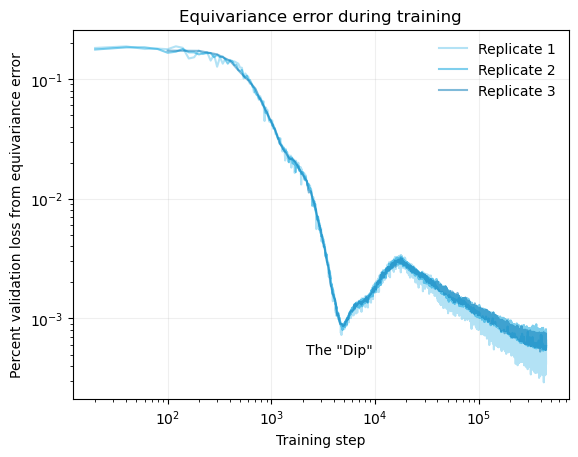

In [16]:
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error_1',
    color = '#68c7ec',
    label = 'Replicate 1',
    errorbar = None,
    alpha=0.5,
)
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error_2',
    color = '#00a0dc',
    label = 'Replicate 2',
    errorbar = None,
    alpha=0.5,
)
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error_3',
    color = '#0077b5',
    label = 'Replicate 3',
    errorbar = None,
    alpha=0.5,
)

# sns.despine()
plt.yscale('log')
plt.xscale('log')

plt.ylabel('Percent validation loss from equivariance error')
plt.xlabel('Training step')
plt.title('Equivariance error during training')

plt.grid(alpha = 0.2)
plt.legend(frameon=False)

# thresholds = [0.01, 0.001]
# for threshold in thresholds:
#     x = mdf[mdf['val/pct_loss_from_equiv_error_1'] <= threshold].index[0]

#     plt.text(
#         x,
#         threshold,
#         f'{threshold:.1%} at step {x}',
#         ha='right',
#     );

# draw text for last point
# last_x = mdf.index[-1]
# last_y = mdf['val/pct_loss_from_equiv_error_1'].iloc[-1]
# plt.text(
#     last_x,
#     last_y,
#     f'{last_y:.2%} at step {last_x}',
#     ha='right',
#     va='top',
# );

# draw text at x = 20000
# x = 20_000
# y = mdf['val/pct_loss_from_equiv_error_1'].loc[mdf['_step'] == x].values[0]
# plt.text(
#     x,
#     y,
#     f'{y:.2%} at step {x}',
#     ha='left',
#     va='bottom',
# );

plt.text(4500, 0.0005, 'The "Dip"', ha = 'center')

plt.savefig('escaip-loglog-equivariance_error_training.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

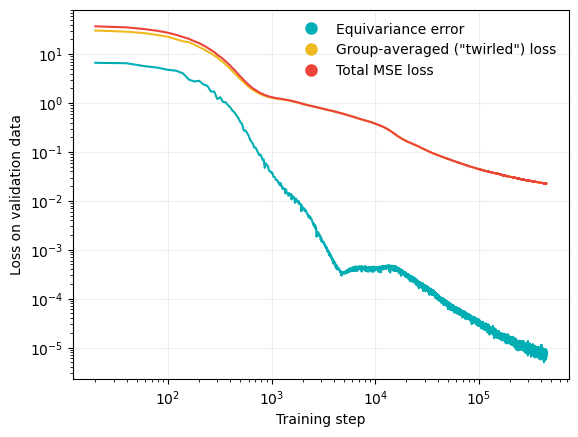

In [9]:
# Loss curves

sns.lineplot(
    data=mdf,
    x='_step',
    y='val/equiv_error_1',
    label = 'Equivariance error',
    color = '#00aeb3',
    errorbar = None,
)
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/mean_pred_error_1',
    label = 'Group-averaged ("twirled") loss',
    color = '#efb920',
    errorbar = None,
)
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/total_mse_1',
    color = '#ec4339',
    label = 'Total MSE loss',
    errorbar = None,
)

# sns.despine()
plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)


# Create custom Line2D objects to represent legend markers
import matplotlib.lines as mlines
equiv_handle = mlines.Line2D([], [], color='#00aeb3', marker='o', linestyle='None',
                          markersize=8, label='Equivariance error')
twirled_handle = mlines.Line2D([], [], color='#efb920', marker='o', linestyle='None',
                           markersize=8, label='Group-averaged ("twirled") loss')
total_handle = mlines.Line2D([], [], color='#ec4339', marker='o', linestyle='None',
                           markersize=8, label='Total MSE loss')
plt.legend(frameon=False, handles=[equiv_handle, twirled_handle, total_handle])
# plt.legend(frameon=False)


plt.xlabel('Training step')
plt.ylabel('Loss on validation data')

plt.savefig('escaip-default-losscurves.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [93]:
print(mdf.columns)

Index(['val/total_mse_1', 'train/grad_norm_1',
       'train/forces_magnitude_error_1', 'train/lr_1', 'train/epoch_1',
       'train/energy_mae_1', '_timestamp_1', 'val/forces_mae_1',
       'val/energy_mse_1', 'train/forces_mse_1',
       ...
       'val/pct_loss_from_equiv_error_3', 'train/energy_rmse_3', 'val/epoch_3',
       'val/forces_mse_3', 'train/energy_mse_3', 'train/grad_norm_3',
       'val/forces_rmse_3', 'train/energy_mae_3', 'val/energy_mae_3',
       '_log step'],
      dtype='object', length=101)


{'pearson': {'correlation': 0.8540703143767137, 'p-value': 0.0}, 'spearman': {'correlation': 0.7468192098759263, 'p-value': 0.0}}


Text(0.48232677573224714, 0.00021227474010869038, 'Pearson R: 0.85\nSpearman ρ: 0.75')

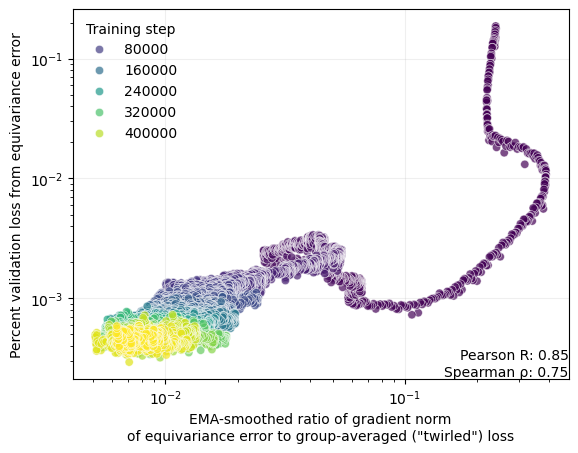

In [130]:
mdf['_log step'] = np.log(mdf['_step'])

def get_correlation_stats(col1, col2, log_scale=False):
    from scipy.stats import pearsonr, spearmanr
    filt_mdf = mdf[~np.isnan(mdf[col1]) & ~np.isnan(mdf[col2])]
    if log_scale:
        filt_mdf = filt_mdf[filt_mdf[col1] > 0]
        filt_mdf = filt_mdf[filt_mdf[col2] > 0]
        filt_mdf[col1] = np.log(filt_mdf[col1])
        filt_mdf[col2] = np.log(filt_mdf[col2])
    corr_pearson, p_pearson = pearsonr(filt_mdf[col1], filt_mdf[col2])
    corr_spearman, p_spearman = spearmanr(filt_mdf[col1], filt_mdf[col2])
    return {
        'pearson': {
            'correlation': corr_pearson,
            'p-value': p_pearson
        },
        'spearman': {
            'correlation': corr_spearman,
            'p-value': p_spearman
        }
    }

x_col = 'val/grad_norm_ratio_equiv_over_mean'
y_col = 'val/pct_loss_from_equiv_error_1'

mdf[f'{x_col}_ema'] = mdf[x_col].ewm(span=100, adjust=False).mean()
x_col = f'{x_col}_ema'

corr_stats = get_correlation_stats(x_col, y_col, log_scale=True)
print(corr_stats)

viridis_cmap = plt.get_cmap('viridis', mdf['_step'].nunique())

sns.scatterplot(
    data=mdf,
    x=x_col,
    y=y_col,
    # hue = '_log step',
    hue = '_step',
    palette = 'viridis',
    # alpha = 0.2,
    alpha = 0.7,
)
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha = 0.2)

plt.legend(frameon=False, title = 'Training step')

left, right = plt.xlim()
bottom, top = plt.ylim()

plt.ylabel('Percent validation loss from equivariance error')
plt.xlabel('EMA-smoothed ratio of gradient norm\nof equivariance error to group-averaged ("twirled") loss')
plt.text( right, bottom, 
         f'Pearson R: {corr_stats["pearson"]["correlation"]:.2f}\nSpearman ρ: {corr_stats["spearman"]["correlation"]:.2f}', 
         ha='right', va='bottom')
